# ASSIGNMENT 2: Machine Learning
## Review Buster - NLP Classification Model
---

## I. DATA EXPLORATION

*Online Shopping Industry for Goods & Services has witnessed intense growth in the recent year - with just a few click, we can order products with ease, in which before, would be time-consuming*
<br>
<br>
**However** *that does not mean Online Shopping has fully replaced In-store purchase, there still exists problem related to authenticity of the good and services*
<br><br>
Since customers, during online shopping, would have no sort of awareness of how the *product* would be like in real life <br>
Their main source of information would then just be the **reviews** that previous users have left behind for them. Anyone, who admitted themselves to be previous customers of any certain goods or services, can freely active in these commenting conversation. <br>
By this, we have allowed the one and only source of information to be flawed and untrustworthy <br>
<h5 style="text-align: center;"><b><i>How can we confirm for sure that those reviews are legitimate?</i></b></h5>
<h5 style="text-align: center;"><b><i>And those are not belong from random people who are just trying to manipulate the review section?</i></b></h5>

Awaring of such major problem for the user experience while Online Shopping, I have made myself to create a Machine Learning model, whose main purpose is to correctly *classify* whether a Review is *"truthful"* or *"deceptive"* <br>
<br>
*This model version would first just deal with **Hotel Reviews*** <br><br>


The dataset used for training process is collected from **Kaggle** - consisting of 1600 reviews, both truthful and deceptive / coming from numerous sources of the internet, of 20 hotels in Chicago. <br>
The selected dataset is shown in the following.

In [1]:
from pathlib import Path
import pandas as pd

data_path = Path("data/deceptive-opinion.csv")
df = pd.read_csv(data_path)
df.head()


,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


### 1. Column names, data types, and descriptions

The table shows each column, its pandas data type, its analytical type, and what it represents. A pandas data type describes how values are stored; an analytical type describes how the values should be interpreted. Neither describes the spelling of the column name.

In [2]:
column_descriptions = {
    "deceptive": "Review label: truthful or deceptive",
    "hotel": "Hotel associated with the review",
    "polarity": "Review sentiment: positive or negative",
    "source": "Platform or collection source of the review",
    "text": "Full written hotel review",
}

analytical_types = {
    "deceptive": "Nominal (binary)",
    "hotel": "Nominal",
    "polarity": "Ordinal (negative < positive)",
    "source": "Nominal",
    "text": "Unstructured text",
}

column_info = pd.DataFrame({
    "Column name": df.columns,
    "Pandas data type": df.dtypes.astype(str).to_numpy(),
    "Analytical type": [analytical_types[column] for column in df.columns],
    "Column description": [column_descriptions[column] for column in df.columns],
})
column_info


,Column name,Pandas data type,Analytical type,Column description
0,deceptive,object,Nominal (binary),Review label: truthful or deceptive
1,hotel,object,Nominal,Hotel associated with the review
2,polarity,object,Ordinal (negative < positive),Review sentiment: positive or negative
3,source,object,Nominal,Platform or collection source of the review
4,text,object,Unstructured text,Full written hotel review


**Observation:** Pandas reads all five columns as `object` because their values are written as text. Their roles in the model are different: `deceptive` is the target, `text` and `polarity` are the planned predictive inputs, and `hotel` and `source` are retained for evaluation and auditing. <br><br>

We will encode the target as `truthful = 0` and `deceptive = 1`, and polarity as `negative = 0` and `positive = 1`. We will keep hotel and source names as strings rather than assigning them arbitrary numeric values. The preprocessing decisions and their reasons are detailed in Section II. <br><br>

The review text will later be turned into numerical NLP features, such as TF-IDF values. We must fit the text representation on training reviews only so that information from the test reviews does not leak into training.

### 2. Missing values and duplicate reviews

First, we check whether any fields are missing. We also check for empty or whitespace-only values, which are not always reported as missing by pandas. For duplicates, the counts below refer to **additional copies after the first occurrence**; the displayed rows include both the original and its copy.

#### Missing and blank values

In [3]:
from IPython.display import display

missing_by_column = df.isna().sum().rename("Missing values").to_frame()
blank_by_column = df.apply(
    lambda column: column.astype("string").str.strip().eq("").fillna(False)
).sum()
missing_by_column["Blank / whitespace-only values"] = blank_by_column
display(missing_by_column)

missing_rows = df.loc[df.isna().any(axis=1)]
blank_rows = df.loc[df.apply(
    lambda column: column.astype("string").str.strip().eq("").fillna(False)
).any(axis=1)]
print(f"Rows with at least one missing value: {len(missing_rows)}")
print(f"Rows with at least one blank / whitespace-only value: {len(blank_rows)}")
if not missing_rows.empty:
    display(missing_rows)
if not blank_rows.empty:
    display(blank_rows)


,Missing values,Blank / whitespace-only values
deceptive,0,0
hotel,0,0
polarity,0,0
source,0,0
text,0,0


Rows with at least one missing value: 0
Rows with at least one blank / whitespace-only value: 0


#### Duplicate rows

In [4]:
duplicate_rows = df.loc[df.duplicated(keep=False)].copy()
print(f"Additional duplicate rows: {df.duplicated().sum()}")
print(f"Rows involved in duplicate groups: {len(duplicate_rows)}")
if duplicate_rows.empty:
    print("No duplicate rows found.")
else:
    with pd.option_context("display.max_colwidth", None):
        display(duplicate_rows)


Additional duplicate rows: 4
Rows involved in duplicate groups: 8


,deceptive,hotel,polarity,source,text
803,truthful,omni,negative,Web,"My daughter and I woke in the morning wanting to go swimming. When we arrived at the pool the water was covered by a white scum. I then attempted to use both of the phones at the pool, one white phone and one emergency red phone, to call the desk. Both were out of service!!!! I am glad there wasn't an emergency. As we were exited the pool area I ran into a hotel employee and told her about the problems and then asked her to call us when the pool was clean.... never heard back.\n"
847,truthful,omni,negative,Web,"The Omni was chosen for it's location whichworked out perfectly. The bedding was wondeful and everything seemed fairly clean ...until...I sat down in the tub...there was BLACK MOLD in the soap holder, in the cracks on the walls between the tile, all under the tile overhang above the tub and completely around the toilet bowl. Needless to say I drained the tub and took a shower...I really don't care for showers. Oh yes...the toilet leaked as well...The staff were very helpful but I was disappointed. I travel extensively and don't think I will return. we needed color copies for a business meeting and their printer was broken, so the man in the business center took the jump drive to another part of the hotel, printed the presentation and delivered it to our room. They try! We booked online for a weekend package and got a room on the 10th floor with a view of the windows of another building...but we weren't there too much.\n"
853,truthful,omni,negative,Web,"My daughter and I woke in the morning wanting to go swimming. When we arrived at the pool the water was covered by a white scum. I then attempted to use both of the phones at the pool, one white phone and one emergency red phone, to call the desk. Both were out of service!!!! I am glad there wasn't an emergency. As we were exited the pool area I ran into a hotel employee and told her about the problems and then asked her to call us when the pool was clean.... never heard back.\n"
862,truthful,omni,negative,Web,"The Omni was chosen for it's location whichworked out perfectly. The bedding was wondeful and everything seemed fairly clean ...until...I sat down in the tub...there was BLACK MOLD in the soap holder, in the cracks on the walls between the tile, all under the tile overhang above the tub and completely around the toilet bowl. Needless to say I drained the tub and took a shower...I really don't care for showers. Oh yes...the toilet leaked as well...The staff were very helpful but I was disappointed. I travel extensively and don't think I will return. we needed color copies for a business meeting and their printer was broken, so the man in the business center took the jump drive to another part of the hotel, printed the presentation and delivered it to our room. They try! We booked online for a weekend package and got a room on the 10th floor with a view of the windows of another building...but we weren't there too much.\n"
995,truthful,affinia,negative,Web,"I'd been searching for a cool, non-chain hotel for a weekend getaway with my boyfriend. I thought I'd found a winner in the Affinia... SOO disappointed!! In spite of the fact that our reservation was for two adults, we arrived to find our room had a DOUBLE bed. What?! I was floored, but after a delayed flight and a 2 hour cab ride, was too tired to make a fuss. We were hungry after all the delays and planned on attending an event that night, so we called for room service hoping to keep it simple. I was told that room service would call ME back to take my order...and nothing happened. I didn't want to be late to our event so we ended up going to the restaurant downstairs. Nothing special; entree, dessert and NAB for two still came out to $*...I am no hayseed, I'm WELL aware that everything costs more in Chicago, but this just wasn't worth it. Our room was by the elevator w/ parking garage view...the bathroom was tiny, shower curtain was stained, 

#### Duplicate review text

In [5]:
duplicate_text_rows = df.loc[df.duplicated(subset=["text"], keep=False)].copy()
duplicate_review_details = (
    duplicate_text_rows.reset_index(names="Row index")
    .groupby("text", sort=False)
    .agg(**{"Row indices": ("Row index", list), "Occurrences": ("Row index", "size")})
    .reset_index()
    .rename(columns={"text": "Review text"})
    [["Row indices", "Occurrences", "Review text"]]
)
print(f"Additional rows repeating an earlier review text: {df.duplicated(subset=['text']).sum()}")
print(f"Distinct review texts that appear more than once: {len(duplicate_review_details)}")
if duplicate_review_details.empty:
    print("No duplicate review text found.")
else:
    with pd.option_context("display.max_colwidth", None):
        display(duplicate_review_details)


Additional rows repeating an earlier review text: 4
Distinct review texts that appear more than once: 4


,Row indices,Occurrences,Review text
0,"[803, 853]",2,"My daughter and I woke in the morning wanting to go swimming. When we arrived at the pool the water was covered by a white scum. I then attempted to use both of the phones at the pool, one white phone and one emergency red phone, to call the desk. Both were out of service!!!! I am glad there wasn't an emergency. As we were exited the pool area I ran into a hotel employee and told her about the problems and then asked her to call us when the pool was clean.... never heard back.\n"
1,"[847, 862]",2,"The Omni was chosen for it's location whichworked out perfectly. The bedding was wondeful and everything seemed fairly clean ...until...I sat down in the tub...there was BLACK MOLD in the soap holder, in the cracks on the walls between the tile, all under the tile overhang above the tub and completely around the toilet bowl. Needless to say I drained the tub and took a shower...I really don't care for showers. Oh yes...the toilet leaked as well...The staff were very helpful but I was disappointed. I travel extensively and don't think I will return. we needed color copies for a business meeting and their printer was broken, so the man in the business center took the jump drive to another part of the hotel, printed the presentation and delivered it to our room. They try! We booked online for a weekend package and got a room on the 10th floor with a view of the windows of another building...but we weren't there too much.\n"
2,"[995, 1014]",2,"I'd been searching for a cool, non-chain hotel for a weekend getaway with my boyfriend. I thought I'd found a winner in the Affinia... SOO disappointed!! In spite of the fact that our reservation was for two adults, we arrived to find our room had a DOUBLE bed. What?! I was floored, but after a delayed flight and a 2 hour cab ride, was too tired to make a fuss. We were hungry after all the delays and planned on attending an event that night, so we called for room service hoping to keep it simple. I was told that room service would call ME back to take my order...and nothing happened. I didn't want to be late to our event so we ended up going to the restaurant downstairs. Nothing special; entree, dessert and NAB for two still came out to $*...I am no hayseed, I'm WELL aware that everything costs more in Chicago, but this just wasn't worth it. Our room was by the elevator w/ parking garage view...the bathroom was tiny, shower curtain was stained, funky toilet seat/lid, and the vanity featured that 'rude awakening' lighting normally found in low-rent dressing rooms, i.e., 'Holy crap, have I looked that bad this whole time?!' If you're a traveler who likes using the in-room coffeemaker, they charge for their chintzy coffees (I don't use these, but... come on). Nice enough ambience in the upstairs bar, but weak drinks... That night, our bed was so tiny and uncomfortable that I almost asked to switch rooms. But the Marathon was that weekend; the hotel was so busy I didn't want to be a pest. I can't believe I was so impressed with this place online. Next time I'll happily pay more to stay someplace that's actually a treat.\n"
3,"[1085, 1109]",2,"Very disappointed in our stay in Chicago Monoco. We have stayed many times elsewhere, primarily in washington DC and are accustomed to great customer service, beverages like water or soda at the wine bar, coffee and papers in the morning, help with bags. Not only did the Chicago monoco do none of these things, the staff was not helpful, either. Requests were not honored and the staff did not seem happy to be there. YOu got the feeling you were 'bothering' people if you asked a question. No bellman, the doorman did not open the door or help with bags. Even though we were traveling with a child, I had to request a fish when they did not bring it. Really baffling.. as we love the Monoco in Washington.\n"


**Observation:** There are no missing or blank values in the 1,600 reviews. We found 4 exact duplicate pairs: 4 extra full rows, or 8 rows when we show both copies. The same 4 pairs are also the only repeated review texts, and their other column values match as well. Before splitting the data for training and testing, we should remove the extra copies so the same review cannot appear in both sets and make the model look better than it really is. The raw dataset stays unchanged here; this section only identifies the records that will need attention during preprocessing.

### 3. Hotels, sources, labels, and polarity

The following counts describe the **raw 1,600-row dataset**. The four extra duplicate rows identified above are still included here; we will handle them before splitting the data for modelling.

#### Number of hotels and reviews per hotel

In [6]:
hotel_count = df["hotel"].nunique()
print(f"Number of hotels: {hotel_count}")
hotel_counts = df["hotel"].value_counts().sort_index().rename_axis("Hotel").reset_index(name="Review count")
hotel_counts


Number of hotels: 20


,Hotel,Review count
0,affinia,80
1,allegro,80
2,amalfi,80
3,ambassador,80
4,conrad,80
5,fairmont,80
6,hardrock,80
7,hilton,80
8,homewood,80
9,hyatt,80


#### Number of sources and reviews per source

In [7]:
source_count = df["source"].nunique()
print(f"Number of sources: {source_count}")
source_counts = df["source"].value_counts().rename_axis("Source").reset_index(name="Review count")
source_counts


Number of sources: 3


,Source,Review count
0,MTurk,800
1,TripAdvisor,400
2,Web,400


#### Truthful and deceptive review counts

In [8]:
label_counts = (
    df["deceptive"].value_counts()
    .reindex(["truthful", "deceptive"])
    .rename_axis("Class")
    .reset_index(name="Review count")
)
label_counts


,Class,Review count
0,truthful,800
1,deceptive,800


#### Positive and negative review counts

The overall polarity split is balanced too.

In [9]:
polarity_counts = (
    df["polarity"].value_counts()
    .reindex(["positive", "negative"])
    .rename_axis("Polarity")
    .reset_index(name="Review count")
)
polarity_counts


,Polarity,Review count
0,positive,800
1,negative,800


#### Truthful and deceptive counts for each hotel

In [10]:
hotel_label_counts = pd.crosstab(df["hotel"], df["deceptive"])
hotel_label_counts = hotel_label_counts.reindex(columns=["truthful", "deceptive"], fill_value=0)
hotel_label_counts["Total"] = hotel_label_counts.sum(axis=1)
hotel_label_counts


deceptive,truthful,deceptive,Total
hotel,,,
affinia,40,40,80
allegro,40,40,80
amalfi,40,40,80
ambassador,40,40,80
conrad,40,40,80
fairmont,40,40,80
hardrock,40,40,80
hilton,40,40,80
homewood,40,40,80


#### Truthful and deceptive counts for each source

In [11]:
source_label_counts = pd.crosstab(df["source"], df["deceptive"])
source_label_counts = source_label_counts.reindex(columns=["truthful", "deceptive"], fill_value=0)
source_label_counts["Total"] = source_label_counts.sum(axis=1)
source_label_counts


deceptive,truthful,deceptive,Total
source,,,
MTurk,0,800,800
TripAdvisor,400,0,400
Web,400,0,400


#### Positive and negative counts within each label

In [12]:
label_polarity_counts = pd.crosstab(df["deceptive"], df["polarity"])
label_polarity_counts = label_polarity_counts.reindex(
    index=["truthful", "deceptive"], columns=["positive", "negative"], fill_value=0
)
label_polarity_counts["Total"] = label_polarity_counts.sum(axis=1)
label_polarity_counts


polarity,positive,negative,Total
deceptive,,,
truthful,400,400,800
deceptive,400,400,800


**Observation:** The dataset has 20 hotels, with 80 reviews from each hotel. Overall, there are 800 truthful and 800 deceptive reviews. Every hotel also has the same balance: 40 truthful and 40 deceptive reviews. This is helpful because neither class dominates the data, and the hotel name alone does not point to one label. It also supports our plan to test the model on hotels it has not seen during training. <br><br>

The positive and negative reviews are evenly distributed too: each label contains 400 positive and 400 negative reviews. Therefore, `polarity` alone does not tell us whether a review is truthful or deceptive, and these counts do not support the idea that deceptive reviews are more often positive in this dataset. We will still include polarity alongside the review text as a predictive feature and assess whether it improves performance. We will also compare performance on positive and negative reviews. <br><br>

**The `source` column needs particular attention.** Every `MTurk` review is labelled deceptive, while every `TripAdvisor` and `Web` review is labelled truthful. In this CSV, `source` reveals the class perfectly. **We must exclude `source`, including any encoded version of it, from training and prediction features.** Otherwise, the model could appear to perform well by learning where a review came from rather than learning from its text. We will keep `source` only for dataset auditing and reporting, and discuss possible source-related writing patterns as a limitation.

### 4. Review length distribution

Now we take a closer look at the reviews themselves. We measure length in three ways: **characters** (including spaces and punctuation), **words** (separated by whitespace), and **sentences** (estimated by splitting after `.`, `!`, or `?`). Sentence counts are approximate because punctuation does not always mark a sentence boundary correctly. The results below use the raw 1,600 reviews, including the four extra duplicate rows.

#### Central tendency and spread

Reviews are grouped by length unit below, so the overall, truthful, and deceptive values can be compared together. Thicker lines separate the three units.

In [13]:
import re

# Keep the raw dataframe unchanged; add length measures in a separate copy.
length_df = df.copy()
length_df["Characters"] = length_df["text"].str.len()
length_df["Words"] = length_df["text"].str.split().str.len()

def count_sentences(review):
    parts = re.split(r"(?<=[.!?])\s+", review.strip())
    return sum(bool(part.strip()) for part in parts)

length_df["Sentences"] = length_df["text"].map(count_sentences)

length_rows = []
for unit in ["Characters", "Words", "Sentences"]:
    for group, subset in [
        ("All", length_df),
        ("Truthful", length_df[length_df["deceptive"] == "truthful"]),
        ("Deceptive", length_df[length_df["deceptive"] == "deceptive"]),
    ]:
        values = subset[unit]
        length_rows.append({
            "Reviews": group,
            "Length unit": unit,
            "Mean": values.mean(),
            "Median": values.median(),
            "Standard deviation": values.std(),
            "Q1": values.quantile(0.25),
            "Q3": values.quantile(0.75),
            "Minimum": values.min(),
            "Maximum": values.max(),
        })
length_summary = pd.DataFrame(length_rows).round(2)

# A visible line before Words and Sentences separates the three length units.
from IPython.display import HTML, display
length_table_style = """<style>
.review-length-table tbody tr:nth-child(4) td,
.review-length-table tbody tr:nth-child(7) td {
    border-top: 3px solid #808080;
}
</style>"""
length_table_html = length_summary.to_html(
    index=False,
    border=0,
    classes="review-length-table",
    formatters={
        "Mean": "{:.2f}".format,
        "Median": "{:g}".format,
        "Standard deviation": "{:.2f}".format,
        "Q1": "{:g}".format,
        "Q3": "{:g}".format,
        "Minimum": "{:.0f}".format,
        "Maximum": "{:.0f}".format,
    },
)
display(HTML(length_table_style + length_table_html))


Reviews,Length unit,Mean,Median,Standard deviation,Q1,Q3,Minimum,Maximum
All,Characters,806.39,700,467.26,487,987.5,151,4159
Truthful,Characters,821.02,710.5,484.66,491,993.25,168,4159
Deceptive,Characters,791.77,680.5,449.02,483.75,985,151,4075
All,Words,148.78,128,87.34,88,182.25,25,784
Truthful,Words,150.91,130,89.81,89,183,30,749
Deceptive,Words,146.64,125,84.79,88,182,25,784
All,Sentences,9.56,8,5.51,6,12,1,58
Truthful,Sentences,10.10,9,6.11,6,12,1,58
Deceptive,Sentences,9.02,8,4.78,6,11,1,35


#### Overall word-count distribution

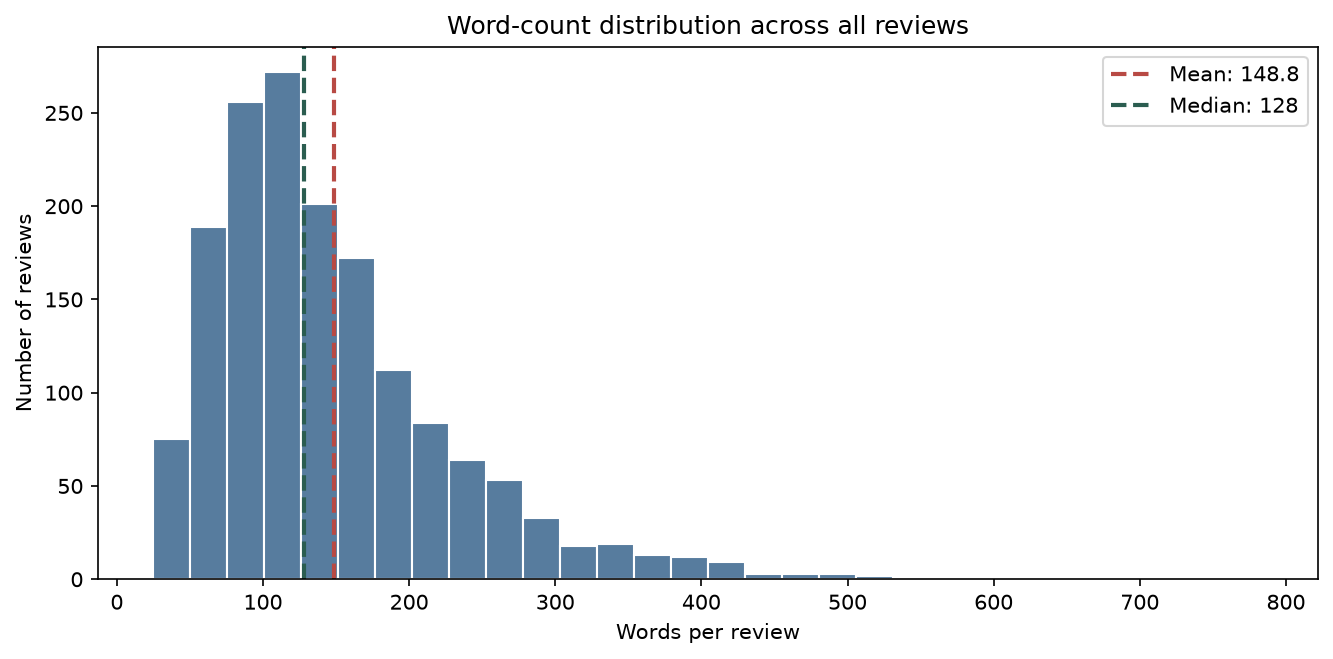

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(length_df["Words"], bins=30, color="#577C9E", edgecolor="white")
ax.axvline(length_df["Words"].mean(), color="#B84A44", linestyle="--", linewidth=2,
           label=f"Mean: {length_df['Words'].mean():.1f}")
ax.axvline(length_df["Words"].median(), color="#2B5D50", linestyle="--", linewidth=2,
           label=f"Median: {length_df['Words'].median():.0f}")
ax.set(title="Word-count distribution across all reviews", xlabel="Words per review", ylabel="Number of reviews")
ax.legend()
fig.tight_layout()
plt.show()


#### Length distributions by class

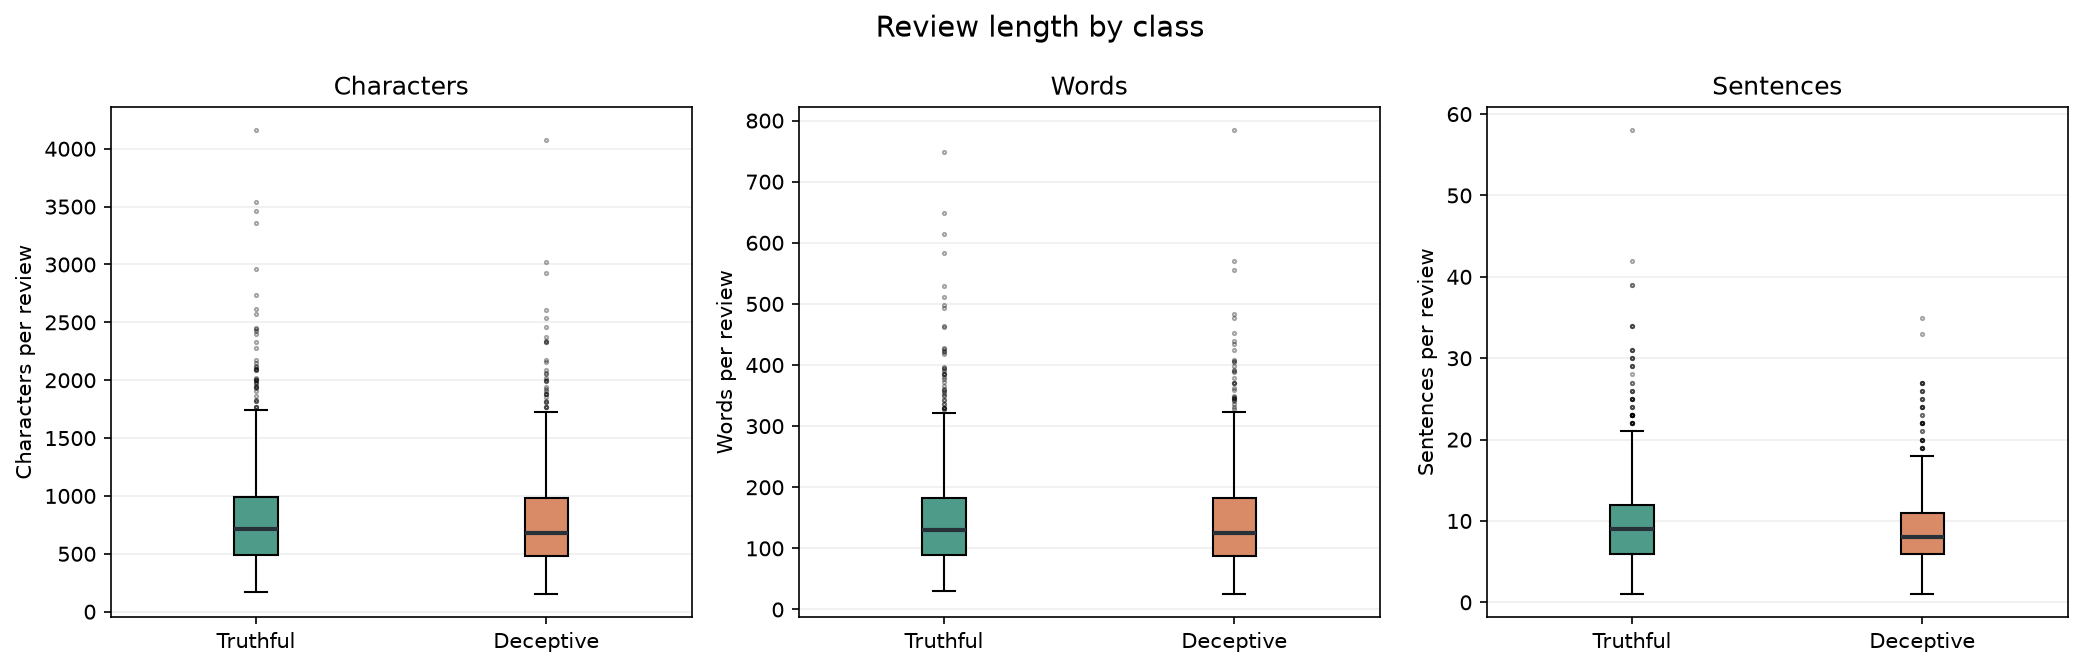

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
colors = ["#4E9B8A", "#D98B67"]
for ax, unit in zip(axes, ["Characters", "Words", "Sentences"]):
    groups = [
        length_df.loc[length_df["deceptive"] == "truthful", unit],
        length_df.loc[length_df["deceptive"] == "deceptive", unit],
    ]
    result = ax.boxplot(groups, patch_artist=True,
                        medianprops={"color": "#263238", "linewidth": 2},
                        flierprops={"marker": ".", "markersize": 3, "alpha": 0.35})
    for patch, color in zip(result["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_xticks([1, 2], ["Truthful", "Deceptive"])
    ax.set(title=unit, ylabel=f"{unit} per review")
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Review length by class", fontsize=14)
fig.tight_layout()
plt.show()


**Observation:** A typical review has around **128 words** (the median), while the mean is higher at **148.78 words**. A smaller number of very long reviews pull the mean upwards, as we can see in the histogram. The standard deviation of **87.34 words** also shows that review lengths vary considerably. <br><br>

Truthful reviews are *slightly* longer than deceptive reviews on average: **150.91 versus 146.64 words**. Their medians are close too, at **130 versus 125 words**. The middle 50% of both groups covers almost the same word-count range, which is clear in the box plots. So, review length by itself does not appear to clearly separate truthful from deceptive reviews. Truthful reviews have a little more spread, particularly in sentence counts, but the groups overlap heavily. <br><br>

We should also be careful when interpreting this difference. In this dataset, `source` and the truthful/deceptive label are strongly connected, so a difference in length could partly reflect how reviews were collected or written for each source. Length is useful to explore, but it should not be treated as a universal sign of deception.

### 5. Vocabulary in truthful and deceptive reviews

Next, we look at the words used in the reviews. For this exploration, words are changed to lowercase, punctuation is ignored, and one-letter tokens are excluded. Words such as `room` and `rooms` are counted separately. The results still describe the raw 1,600 reviews, including the four extra duplicate rows. This is **descriptive analysis only**; the vocabulary used by the final model will be fitted later on training reviews only.

#### Vocabulary size and overlap

In [16]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# This vectorizer is for describing the raw corpus only. We will fit a new one
# on training reviews after the train/test split when building the model.
vocab_vectorizer = CountVectorizer()
review_word_counts = vocab_vectorizer.fit_transform(df["text"])
vocabulary = vocab_vectorizer.get_feature_names_out()
truthful_mask = (df["deceptive"] == "truthful").to_numpy()
deceptive_mask = (df["deceptive"] == "deceptive").to_numpy()
truthful_token_counts = np.asarray(review_word_counts[truthful_mask].sum(axis=0)).ravel()
deceptive_token_counts = np.asarray(review_word_counts[deceptive_mask].sum(axis=0)).ravel()
truthful_vocab = truthful_token_counts > 0
deceptive_vocab = deceptive_token_counts > 0

vocab_summary = pd.DataFrame({
    "Measure": ["Total word occurrences", "Distinct words", "Words found only in this group"],
    "Truthful": [
        truthful_token_counts.sum(),
        truthful_vocab.sum(),
        (truthful_vocab & ~deceptive_vocab).sum(),
    ],
    "Deceptive": [
        deceptive_token_counts.sum(),
        deceptive_vocab.sum(),
        (deceptive_vocab & ~truthful_vocab).sum(),
    ],
})
print(f"Distinct words across all reviews: {len(vocabulary):,}")
print(f"Words used by both groups: {(truthful_vocab & deceptive_vocab).sum():,}")
vocab_summary


Distinct words across all reviews: 9,571
Words used by both groups: 3,936


,Measure,Truthful,Deceptive
0,Total word occurrences,114567,110695
1,Distinct words,7182,6325
2,Words found only in this group,3246,2389


#### Common words

Words such as `the`, `and`, and `to` occur often in both groups. To make the hotel-related words easier to see, the table below hides common English stop words **for display only**.

In [17]:
# Hide common English stop words for this display only; they remain in the
# vocabulary counts above and are not removed from the future model by default.
content_word_indices = [
    i for i, word in enumerate(vocabulary)
    if word not in ENGLISH_STOP_WORDS and not word.isdigit()
]
truthful_top = sorted(content_word_indices, key=lambda i: -truthful_token_counts[i])[:10]
deceptive_top = sorted(content_word_indices, key=lambda i: -deceptive_token_counts[i])[:10]
common_words = pd.DataFrame({
    "Rank": range(1, 11),
    "Truthful word": vocabulary[truthful_top],
    "Truthful occurrences": truthful_token_counts[truthful_top],
    "Deceptive word": vocabulary[deceptive_top],
    "Deceptive occurrences": deceptive_token_counts[deceptive_top],
})
common_words


,Rank,Truthful word,Truthful occurrences,Deceptive word,Deceptive occurrences
0,1,hotel,1497,hotel,1840
1,2,room,1412,room,1408
2,3,stay,601,chicago,1040
3,4,great,549,stay,703
4,5,chicago,487,service,430
5,6,staff,441,staff,398
6,7,service,389,rooms,347
7,8,location,349,like,329
8,9,stayed,349,great,316
9,10,night,342,stayed,316


#### Words that differ between groups

The percentages below show how many reviews contain each word. A review counts only once for a word, even if it repeats that word several times. Since each class has 800 reviews, we can compare the percentages directly.

In [18]:
# A review counts once for a word, even if it repeats that word many times.
selected_words = [
    "chicago", "experience", "luxury", "recommend",
    "location", "floor", "great", "bathroom",
]
word_lookup = {word: i for i, word in enumerate(vocabulary)}
truthful_document_counts = np.asarray((review_word_counts[truthful_mask] > 0).sum(axis=0)).ravel()
deceptive_document_counts = np.asarray((review_word_counts[deceptive_mask] > 0).sum(axis=0)).ravel()
word_prevalence = pd.DataFrame({
    "Word": selected_words,
    "Truthful reviews (%)": [
        truthful_document_counts[word_lookup[word]] / truthful_mask.sum() * 100
        for word in selected_words
    ],
    "Deceptive reviews (%)": [
        deceptive_document_counts[word_lookup[word]] / deceptive_mask.sum() * 100
        for word in selected_words
    ],
}).round(1)
word_prevalence


,Word,Truthful reviews (%),Deceptive reviews (%)
0,chicago,44.0,77.0
1,experience,11.5,23.9
2,luxury,1.1,11.9
3,recommend,13.4,21.8
4,location,38.4,15.0
5,floor,19.5,6.2
6,great,41.4,27.1
7,bathroom,22.6,13.1


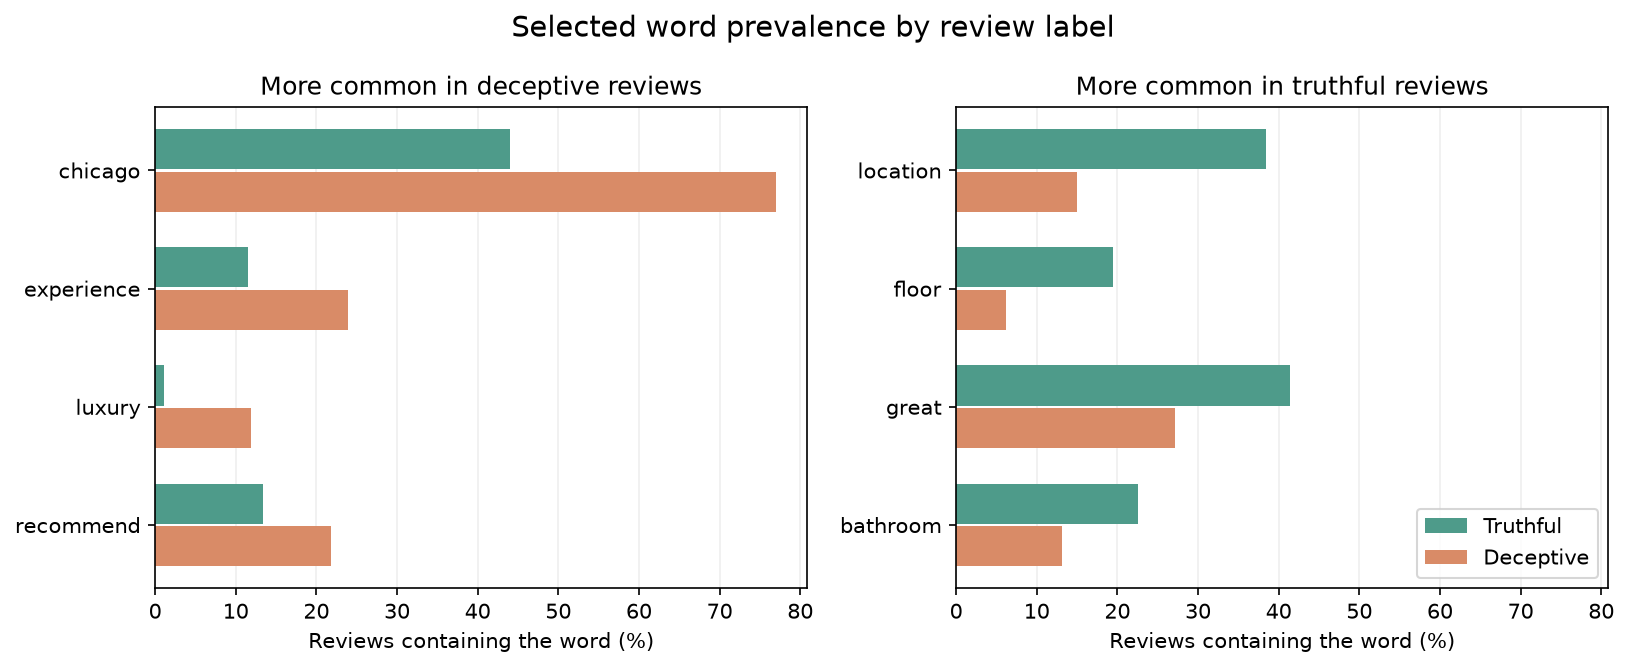

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
for ax, words, title in [
    (axes[0], selected_words[:4], "More common in deceptive reviews"),
    (axes[1], selected_words[4:], "More common in truthful reviews"),
]:
    subset = word_prevalence.set_index("Word").loc[words]
    positions = np.arange(len(words))
    ax.barh(positions - 0.18, subset["Truthful reviews (%)"], height=0.34,
            color="#4E9B8A", label="Truthful")
    ax.barh(positions + 0.18, subset["Deceptive reviews (%)"], height=0.34,
            color="#D98B67", label="Deceptive")
    ax.set_yticks(positions, words)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
    ax.set_xlabel("Reviews containing the word (%)")
axes[1].legend(loc="lower right")
fig.suptitle("Selected word prevalence by review label", fontsize=14)
fig.tight_layout()
plt.show()


**Observation:** Truthful and deceptive reviews share many of their common words. Both groups talk about hotels, rooms, stays, and service, so a word such as `hotel` or `room` does not tell us much about the review label by itself. Truthful reviews contain more distinct words overall, although many words found in only one group appear very rarely. This means the two vocabularies are not as separate as the raw unique-word counts might first suggest. <br><br>

There is a possible difference in *what* the reviews choose to describe. In this corpus, deceptive reviews more often use broader terms such as `experience` and `luxury`, and they mention `chicago` and `recommend` more often. Truthful reviews more often mention smaller details of a stay, such as the `location`, `floor`, and `bathroom`. This suggests that some deceptive reviews give a more general account, while some truthful reviews include more specific details about the hotel. However, it is only a pattern in these reviews: a deceptive writer can include specific details, and a truthful reviewer can write a general review. <br><br>

**Why we must be careful:** In this dataset, every deceptive review comes from `MTurk`, and every truthful review comes from `TripAdvisor` or `Web`. So if a word such as `luxury` is more common in deceptive reviews, we cannot tell whether that is because of deception or because MTurk writers used different language. We can describe the difference here, but we cannot claim that the word is a universal sign of a fake review. When we build the model, we will first set aside the test reviews, then let TF-IDF learn its vocabulary and word weights from the training reviews only. That prevents words from the final test set from influencing the training process.

## II. DATA PREPROCESSING

### 1. Roles and encoding of the non-review attributes

**`deceptive` — target label.** We map `truthful` to **0** and `deceptive` to **1**. This is the value the model learns to predict, so it must never be included among the input features. With deceptive encoded as 1, metrics reported for the positive class will describe detection of deceptive reviews.

**`hotel` — evaluation grouping.** We keep the hotel names as strings and exclude them from the predictive features. The raw dataset contains 20 hotels, each with 40 truthful and 40 deceptive reviews. We plan to keep all reviews of a given hotel in the same data split. Testing on held-out hotels will show how well the model handles reviews of hotels it did not encounter during training. The name itself does not need numerical encoding for this purpose.

**`source` — dataset auditing.** We keep the original source names but exclude them from training and prediction. Every MTurk review is labelled deceptive, whereas every TripAdvisor and Web review is labelled truthful. Including source would give the model a direct shortcut to the target. By *auditing*, we mean examining the dataset's collection patterns and checking whether they could distort our conclusions. We use source to identify and explain this bias, not to make predictions. Excluding the column cannot remove any source-related writing patterns already present in the review text, so this remains a limitation of the study.

**`polarity` — predictive feature.** We map `negative` to **0** and `positive` to **1**, and include this value alongside the processed review text. We want to test whether polarity contributes useful information when combined with the words of a review. In the raw data, both the truthful and deceptive groups contain 400 positive and 400 negative reviews. Polarity alone therefore does not distinguish the two labels, and these data do not support the hypothesis that deceptive reviews are more likely to be positive. We will compare a text-only baseline with a text-plus-polarity model on the same held-out data to measure any contribution, and examine results separately for positive and negative reviews.

Because polarity is a model input, a future prediction must receive both review text and a positive/negative polarity value. If that value is unavailable, a separate method would have to infer it from the text, and the combined process would need evaluation.

In [20]:
# Work on a copy so the exploration dataframe keeps its original labels.
preprocessed_df = df.copy()

label_mapping = {"truthful": 0, "deceptive": 1}
polarity_mapping = {"negative": 0, "positive": 1}

# Reject unexpected or missing values instead of silently creating missing codes.
for column, mapping in [("deceptive", label_mapping), ("polarity", polarity_mapping)]:
    unknown_values = set(preprocessed_df[column].dropna().unique()) - set(mapping)
    if preprocessed_df[column].isna().any() or unknown_values:
        raise ValueError(f"Unexpected values in {column}: {unknown_values}")
    preprocessed_df[column] = preprocessed_df[column].map(mapping).astype("int8")

print("Column types after encoding:")
print(preprocessed_df.dtypes.to_string())
print("\nCounts by encoded target and polarity:")
print(pd.crosstab(preprocessed_df["deceptive"], preprocessed_df["polarity"]).to_string())


Column types after encoding:
deceptive      int8
hotel        object
polarity       int8
source       object
text         object

Counts by encoded target and polarity:
polarity     0    1
deceptive          
0          400  400
1          400  400


In [21]:
preprocessed_df.groupby(["deceptive", "polarity"], sort=True).head(2).sort_index()

,deceptive,hotel,polarity,source,text
0,0,conrad,1,TripAdvisor,"We stayed for a one night getaway with family on a thursday. Triple AAA rate of 173 was a steal. 7th floor room complete with 44in plasma TV bose stereo, voss and evian water, and gorgeous bathroom(no tub but was fine for us) Concierge was very helpful. You cannot beat this location... Only flaw was breakfast was pricey and service was very very slow(2hours for four kids and four adults on a friday morning) even though there were only two other tables in the restaurant. Food was very good so it was worth the wait. I would return in a heartbeat. A gem in chicago... \n"
1,0,hyatt,1,TripAdvisor,"Triple A rate with upgrade to view room was less than $200 which also included breakfast vouchers. Had a great view of river, lake, Wrigley Bldg. & Tribune Bldg. Most major restaurants, Shopping, Sightseeing attractions within walking distance. Large room with a very comfortable bed. \n"
400,1,fairmont,1,MTurk,"My husband and I visited the Fairmont Chicago Millennium Park for our honeymoon. The customer service was amazing. From the time we booked our packege to the time we checked in everything was absolutely amazing. These people were proficient, respectful and very thoughtful. The Fairmont had a lounge, a wine room, a bar and a restaurant. I couldn't decide where I wanted to go first! After we put our bags up we headed down to the wine room... It was totally delicious. We also got free wine just because it was our honeymoon! Then after a few glasses of wine we hit the spa, once again excellent!! Everything smells like honeysuckle and everyone smiles all the time. We stayed in the gold room. Although it was a little bit smaller than I thought it would be I was definitely satisfied with the huge king bed with even bigger pillows. My husband and I relaxed in fluffy white bath robes while we sipped champagne while we watched the sparkling lights of the city. It was a wonderful experience that I will never forget. Four thumbs up! \n"
401,1,conrad,1,MTurk,"My wife and I booked a Deluxe Accessible Room at this beautiful hotel for three nights. The wonderful photos don't do the hotel justice. It couldn't have been a more ideal stay. The room was spacious and and clean, the bathroom sparkling, with every amenity one could imagine. The bed felt like it had been just delivered. Our views of downtown Chicago were spectacular. On top of all of this, the hotel staff was extremely helpful. They explained the best routes to the restaurants we wanted to eat at, and they even went as far as securing us reservations for the places they knew would be busy! Believe everything good that you read. If you visit Chicago, stay at the Conrad Chicago.\n"
800,0,conrad,0,Web,"Booked a room w/ a queen bed for 2 nights for a wonderful NYE, and was rather disappointed. Bed was either the world's smallest queen, or was actually a double, not to mention it was uncomfortably springy. Some of the things in the bathroom had been previously opened and used (q-tips). Lots of noise seemed to carry through the vents as we could hear other rooms rather clearly. When the tv was off, there was a very audible high-pitched humming noise that we could not get rid of unless we unplugged the tv. Hot water was very inconsistent in the shower. It is in a great location, however, next time I will try one of the other hotels in the area like the Intercontinental or Marriott. This might not be too bad if you are passing though quickly on business, but I wouldn't recommend it for a romantic night or two.\n"
801,0,hyatt,0,Web,"I arrived and my friends were already there and visiting a nearby art gallery. They put my name on the reservation and told me to get a key from the front desk when I arrived. The front desk staff gave me the key to my room and I put my stuff away and went to meet the group. We returned late that night and I soon realized the room that my friends were in was not the room that I placed my stuff in that afte

### 2. Removing duplicate rows

In Data Exploration, we found **four exact duplicate pairs**: eight rows are involved, but only four are extra copies. The repeated reviews have the same text and the same values in every other column. All four extra copies are truthful, negative reviews from Web. Keeping them would count those reviews more than once.

Duplicates can affect a classifier in two ways. During training, repeated reviews receive extra weight, which may encourage the model to fit their wording more closely. During evaluation, a random row-level split could place one copy in training and its twin in testing, making the test result look better because the model has already seen that review. Our planned hotel-level split would keep each pair within one hotel, so it prevents that particular cross-split leak; nevertheless, duplicate reviews could still distort training weights and evaluation counts. We therefore remove the extra copies **before splitting**.

The code below assigns the cleaned result back to `preprocessed_df`, our working dataset for the next preprocessing steps, while leaving the raw `df` unchanged. It keeps one instance of each exact row. We expect 1,596 reviews afterward, with 796 truthful and 800 deceptive reviews; the small class difference does not justify adding or removing other reviews just to restore equal counts.

In [22]:
# Remove only extra copies of rows that match in every column.
rows_before = len(preprocessed_df)
preprocessed_df = preprocessed_df.drop_duplicates().reset_index(drop=True)
removed_count = rows_before - len(preprocessed_df)

print(f"Rows before duplicate removal: {rows_before:,}")
print(f"Extra duplicate rows removed: {removed_count}")
print(f"Rows remaining: {len(preprocessed_df):,}")
print(f"Duplicate rows remaining: {preprocessed_df.duplicated().sum()}")
print("\nTarget counts after removal (0 = truthful, 1 = deceptive):")
print(preprocessed_df["deceptive"].value_counts().sort_index().to_string())


Rows before duplicate removal: 1,600
Extra duplicate rows removed: 4
Rows remaining: 1,596
Duplicate rows remaining: 0

Target counts after removal (0 = truthful, 1 = deceptive):
deceptive
0    796
1    800


### 3. Splitting hotels 80/20 for training and validation

We use reviews from **16 hotels for training** and reserve reviews from **four hotels for validation**. I randomly selected **Allegro, Homewood, Knickerbocker, and Monaco** for validation. Their selection was not based on review text, labels, or expected model performance. Every review from these four hotels is excluded from training but remains in the dataset for validation.

We hold out complete hotels because we want to see how the model handles reviews of hotels it has not encountered during training. A random split of individual reviews could put the same hotels in both sets, giving a less direct test of this goal. The split is exactly 80/20 by hotel count and approximately 80/20 by review count. After duplicate removal, the four validation hotels contain:

| Validation hotel | Reviews |
|---|---:|
| Allegro | 80 |
| Homewood | 80 |
| Knickerbocker | 80 |
| Monaco | 79 |
| **Total** | **319** |

Monaco has one fewer review because an extra duplicate row was removed earlier. The resulting training and validation counts are:

| Group | Reviews | Truthful | Deceptive | Negative | Positive |
|---|---:|---:|---:|---:|---:|
| Training | 1,277 | 637 | 640 | 637 | 640 |
| Validation | 319 | 159 | 160 | 159 | 160 |

We check that no hotel appears in both sets and use this same split when comparing the text-only and text-plus-polarity models. Any learned text representation, including TF-IDF vocabulary and weights, must be fitted on training reviews only and then applied to validation reviews. `hotel` is used for grouping and `source` remains available for auditing; neither is a predictive feature. This split gives a clearer measure of performance on unseen hotels, although it does not remove the source bias present in the dataset.

In [23]:
import numpy as np

# Randomly select four complete hotels for validation.
hotel_names = sorted(preprocessed_df["hotel"].unique())
validation_hotels = sorted(np.random.default_rng(42).choice(hotel_names, size=4, replace=False))
is_validation = preprocessed_df["hotel"].isin(validation_hotels)

training_df = preprocessed_df.loc[~is_validation].copy().reset_index(drop=True)
validation_df = preprocessed_df.loc[is_validation].copy().reset_index(drop=True)

training_hotels = set(training_df["hotel"])
held_out_hotels = set(validation_df["hotel"])
assert len(training_hotels) == 16 and len(held_out_hotels) == 4
assert training_hotels.isdisjoint(held_out_hotels)
assert len(training_df) + len(validation_df) == len(preprocessed_df)

hotel_counts = validation_df["hotel"].value_counts().sort_index()
split_counts = pd.DataFrame({
    "Reviews": [len(training_df), len(validation_df)],
    "Truthful (0)": [(part["deceptive"] == 0).sum() for part in (training_df, validation_df)],
    "Deceptive (1)": [(part["deceptive"] == 1).sum() for part in (training_df, validation_df)],
    "Negative (0)": [(part["polarity"] == 0).sum() for part in (training_df, validation_df)],
    "Positive (1)": [(part["polarity"] == 1).sum() for part in (training_df, validation_df)],
}, index=["Training", "Validation"])

print("Validation hotels and review counts:")
print(hotel_counts.to_string())
print("\nTraining and validation distributions:")
print(split_counts.to_string())
print(f"\nHotels shared between sets: {len(training_hotels & held_out_hotels)}")


Validation hotels and review counts:
hotel
allegro          80
homewood         80
knickerbocker    80
monaco           79

Training and validation distributions:
            Reviews  Truthful (0)  Deceptive (1)  Negative (0)  Positive (1)
Training       1277           637            640           637           640
Validation      319           159            160           159           160

Hotels shared between sets: 0


### 4. Review Preprocessing

#### A) Light cleaning of review text

We apply the same light cleaning rules to every review before turning its text into numerical features:

- Lowercase the text.
- Remove simple HTML tags while keeping the words inside them.
- Replace URLs with `<url>`.
- Collapse repeated whitespace into single spaces and trim spaces at the ends.

Lowercasing treats different capitalisations of the same word consistently. Removing tags discards formatting without discarding the review's words. Replacing a URL with `<url>` records that a link appeared without retaining a particular web address. Whitespace cleanup removes unnecessary spaces, tabs, and line breaks. We remove HTML tags before inserting `<url>` so the placeholder is not mistaken for a tag.

In the 1,596 reviews remaining after duplicate removal, there are no HTML tags, one explicit URL, and repeated whitespace in 528 reviews. We keep contractions, numbers, punctuation, and spelling because they may carry useful meaning or writing patterns. After the hotel split, we apply the same fixed rules to both sets and update `preprocessed_df` as the working dataset. These rules learn nothing from the reviews. The later TF-IDF vocabulary and weights will be learned only from training reviews.

In [24]:
import re

# Keep the <url> placeholder if this cell is run again.
html_tag_pattern = re.compile(r"<(?!/?url>)/?[A-Za-z][^>]*>", flags=re.IGNORECASE)
url_pattern = re.compile(r"https?://[^\s<>]+|(?<!\w)www\.[^\s<>]+", flags=re.IGNORECASE)

def replace_url(match):
    matched = match.group(0)
    address = matched.rstrip(".,!?;:)")
    return "<url>" + matched[len(address):]

def clean_review_text(review):
    review = review.lower()
    review = html_tag_pattern.sub(" ", review)
    review = url_pattern.sub(replace_url, review)
    return re.sub(r"\s+", " ", review).strip()

original_text = preprocessed_df["text"].copy()
for frame in (preprocessed_df, training_df, validation_df):
    frame["text"] = frame["text"].map(clean_review_text)

print(f"Reviews with text changed by cleaning: {(original_text != preprocessed_df['text']).sum():,}")
print(f"Reviews containing <url>: {preprocessed_df['text'].str.contains('<url>', regex=False).sum()}")
print(f"Reviews with repeated whitespace remaining: {preprocessed_df['text'].str.contains(r'\s{2,}').sum()}")
print(f"Exact duplicate rows after cleaning: {preprocessed_df.duplicated().sum()}")


Reviews with text changed by cleaning: 1,596
Reviews containing <url>: 1
Reviews with repeated whitespace remaining: 0
Exact duplicate rows after cleaning: 0


#### B) Overview on Feature Extractrions

We will represent each review using **term frequency–inverse document frequency (TF-IDF)**. TF-IDF converts text into numerical features that a prediction model can use. Like a basic *bag-of-words* representation, it records terms appearing in a review. Unlike plain word counts, it gives additional weight to terms that are less common across the training reviews. This helps the model give greater attention to terms that distinguish reviews, although a highly weighted term is not automatically evidence of deception.

For a term $t$ in a review $d$, its TF-IDF weight is calculated by multiplying term frequency (TF) by inverse document frequency (IDF):

$$
\operatorname{tf}(t,d)=\text{number of times }t\text{ appears in }d
$$

$$
\operatorname{idf}(t)=\log\!\left(\frac{N+1}{\operatorname{df}(t)+1}\right)+1
$$

$$
\operatorname{TF\!-\!IDF}(t,d)
=\operatorname{tf}(t,d)\times\operatorname{idf}(t)
$$

Here, $N$ is the number of training reviews, and $\operatorname{df}(t)$ is the number of training reviews containing $t$. We will learn the vocabulary and IDF values from the **training set only**, then apply them to the validation set. We may normalise each review’s completed feature vector afterward; that is a separate step from multiplying TF and IDF.

We will first train two model configurations to examine the contribution of polarity. The **text-only configuration** will use the review’s TF-IDF vector. The **text-plus-polarity configuration** will use that same vector alongside a separate binary polarity feature (`negative = 0`, `positive = 1`). Keeping the text features the same allows us to compare performance with and without polarity. The truthful/deceptive label remains the answer the models learn to predict, not an input feature.

We will then examine whether **lemmatisation** improves the text representation. Lemmatisation converts related word forms toward a base word, such as `rooms` to `room`, allowing them to share a feature. We have chosen lemmatisation over stemming because stemming cuts words more aggressively and may remove parts that carry useful meaning. Lemmatisation may also lose information, so we will test its effect rather than assume it helps.

Combining the polarity and lemmatisation choices gives us four configurations:

| Configuration | Review-text features | Polarity included? |
|---|---|---|
| 1 | TF-IDF without lemmatisation | No |
| 2 | TF-IDF without lemmatisation | Yes |
| 3 | TF-IDF with lemmatisation | No |
| 4 | TF-IDF with lemmatisation | Yes |

All four will use the same hotel-based training and validation split. This allows us to compare the contribution of polarity and lemmatisation under the same evaluation conditions.

#### C) TF - IDF + No lemmatisation

##### C.1) TF-IDF unigram representation

A *unigram* is one token, usually a word. In this representation, each word learned from the training reviews becomes its own TF-IDF feature. For example, the cleaned review `i stayed in clean rooms` may contribute separate features for `i`, `stayed`, `in`, `clean`, and `rooms`. Because this version has **no lemmatisation**, `room` and `rooms` remain different features.

Unigrams give us a relatively simple, interpretable starting point. A word can contribute to predictions even if the exact phrase surrounding it has never appeared in training. The limitation is that unigram features do **not explicitly record neighbouring words or their order**. The model may see `not` and `clean`, but this representation has no separate feature for `not clean`. Section C.2 will test whether adding those short phrase features helps.

For extraction, we will use the already cleaned text in `training_df` and `validation_df`. The proposed starting settings are:

- **Word unigrams only:** one feature per learned word.
- **No lemmatisation or stemming:** retain the cleaned word forms.
- **Keep stop words, negations, and one-letter words:** words such as `not` and `i` may be useful.
- **Exclude words found in only one training review:** use a proposed minimum document frequency of 2.

The minimum-frequency rule aims to reduce features based on one-off typos, hotel-specific names, or unusual wording that the model could memorise without learning a pattern useful for new reviews. It also makes the feature table smaller. **Document frequency counts reviews, not repetitions:** a word used ten times in one training review would still be excluded, while a word used once in each of two training reviews would be kept. A rare word might still be informative, so we will check whether this setting helps rather than assume it does.

We will fit the unigram TF-IDF vectoriser **only on training reviews**, learning both its vocabulary and IDF weights there. We will then use that fitted vectoriser to transform validation reviews. This gives the training and validation feature tables the **same columns in the same order**; a new word found only in validation cannot add a column.

The output will be a sparse feature table with **one row per review and one column per learned unigram**. We will first create text-only training and validation tables. We can then make copies with the existing binary `polarity` column appended for the polarity comparison. Polarity does not affect how TF-IDF is calculated. The `deceptive` labels remain separate as the answers to predict, while `hotel` and `source` are excluded from the predictive features.

**Implementation and first-row check.** The following cell carries out the settings above. `fit_transform` learns the unigram vocabulary and IDF values from training reviews; `transform` applies that fixed representation to validation reviews. We keep the text-only feature tables separate from the label and metadata columns. The processed-review tables combine those features with the existing `deceptive`, `hotel`, `polarity`, and `source` fields for inspection, while omitting readable `text`. Retaining metadata here does not make it a model input.

In [25]:
# NumPy ranks the strongest features in the example row below.
import numpy as np
# Pandas stores and displays the sparse feature tables.
import pandas as pd
from IPython.display import display  # Show the first processed row in the notebook.
from sklearn.feature_extraction.text import TfidfVectorizer  # Count terms and calculate TF-IDF.

unigram_vectorizer = TfidfVectorizer(
    # Start with individual words; Section C.2 will add adjacent word pairs.
    ngram_range=(1, 1),
    # Drop words seen in only one training review to limit one-off features.
    min_df=2,
    # Keep common words, including negations and pronouns that may matter here.
    stop_words=None,
    # Retain one-letter words and contractions; <url> contributes the token "url".
    token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
    lowercase=False,  # The light-cleaning step already lowercased the reviews.
    smooth_idf=True,  # Use the smoothed IDF formula described in Section B.
    norm="l2",  # Scale vectors so length has less influence on their weights.
)

# Learn the vocabulary and IDF values from training reviews only.
train_unigram_matrix = unigram_vectorizer.fit_transform(training_df["text"])
validation_unigram_matrix = unigram_vectorizer.transform(validation_df["text"])

feature_columns = [
    f"tfidf_{word}" for word in unigram_vectorizer.get_feature_names_out()
]
unigram_train_text_df = pd.DataFrame.sparse.from_spmatrix(
    train_unigram_matrix,
    index=training_df.index,
    columns=feature_columns,
)
unigram_validation_text_df = pd.DataFrame.sparse.from_spmatrix(
    validation_unigram_matrix,
    index=validation_df.index,
    columns=feature_columns,
)

metadata_columns = ["deceptive", "hotel", "polarity", "source"]
unigram_training_df = pd.concat(
    [training_df[metadata_columns].copy(), unigram_train_text_df],
    axis=1,
)
unigram_validation_df = pd.concat(
    [validation_df[metadata_columns].copy(), unigram_validation_text_df],
    axis=1,
)

y_train = training_df["deceptive"].copy()
y_validation = validation_df["deceptive"].copy()

assert "text" not in unigram_training_df.columns
assert unigram_training_df.columns.equals(unigram_validation_df.columns)
assert len(y_train) == train_unigram_matrix.shape[0]
assert len(y_validation) == validation_unigram_matrix.shape[0]

first_vector = train_unigram_matrix.getrow(0)
top_positions = np.argsort(first_vector.data)[::-1][:6]
top_columns = [
    feature_columns[first_vector.indices[position]]
    for position in top_positions
]
first_row_preview = unigram_training_df.loc[[0], metadata_columns + top_columns]

print("Training table:", unigram_training_df.shape)
print("Validation table:", unigram_validation_df.shape)
print(f"Unigram features: {len(feature_columns):,}")
print(f"Nonzero features in first training review: {first_vector.nnz}")
display(first_row_preview)


Training table: (1277, 4751)
Validation table: (319, 4751)
Unigram features: 4,747
Nonzero features in first training review: 76


,deceptive,hotel,polarity,source,tfidf_was,tfidf_four,tfidf_evian,tfidf_flaw,tfidf_7th,tfidf_very
0,0,conrad,1,TripAdvisor,0.239441,0.223569,0.185059,0.185059,0.185059,0.177994


**First processed review.** The output displays the first training review with its original non-text fields and its six strongest unigram weights. This review is labelled truthful (`deceptive = 0`), refers to the Conrad hotel, and has positive polarity (`polarity = 1`). The training set produced **4,747 unigram features**, giving each processed training row 4,751 columns when the four retained non-text fields are included. The first review has **76 nonzero unigram weights**; the remaining unigram values in its vector are zero.

This is a **sparse vector**: each vocabulary word has a fixed position, but most words are absent from a particular review. Sparse storage avoids filling memory with all those zeros. The displayed row shows only six weighted words so the result is readable; the full processed table keeps every learned unigram column. The original `training_df` and `validation_df` still contain the cleaned readable text.

##### C.2) TF-IDF unigram and bigram representation

The C.1 representation gives each individual word its own feature but does not explicitly record which words appear next to each other. Here, we keep **all unigram features and add bigrams**, which are sequences of two neighbouring tokens. For example, `not` and `clean` remain separate features, while `not clean` becomes an additional feature. Phrases such as `front desk` can also carry more specific information than either word alone. A unigram-and-bigram representation therefore gives the model limited local word order that the unigram-only representation lacks.

We use the same cleaned training and validation reviews, with no lemmatisation, and keep the C.1 token pattern, stop-word choice, minimum document frequency of 2, IDF smoothing, and L2 normalisation. The **only vectoriser setting changed is `ngram_range=(1, 2)`**. We fit a new vectoriser on training reviews because this representation has a larger vocabulary, then transform validation reviews with that fitted vectoriser. The validation reviews do not determine any vocabulary entries or IDF weights. Polarity remains available as metadata but does not affect text feature extraction.

Adding bigrams may help with short phrases and negation, but it creates many more sparse features. Exact phrases repeat less often than individual words, so a larger vocabulary may also let a model fit wording that does not generalise. We will compare prediction results later rather than assume this representation is better.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

unigram_bigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Keep unigrams and add adjacent two-word phrases
    min_df=2,
    stop_words=None,
    token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
    lowercase=False,
    smooth_idf=True,
    norm="l2",
)

# Learn this larger vocabulary and its IDF values from training reviews only.
train_unigram_bigram_matrix = unigram_bigram_vectorizer.fit_transform(training_df["text"])
validation_unigram_bigram_matrix = unigram_bigram_vectorizer.transform(
    validation_df["text"]
)

unigram_bigram_terms = unigram_bigram_vectorizer.get_feature_names_out()
unigram_bigram_columns = [f"tfidf_{term}" for term in unigram_bigram_terms]
unigram_bigram_train_text_df = pd.DataFrame.sparse.from_spmatrix(
    train_unigram_bigram_matrix,
    index=training_df.index,
    columns=unigram_bigram_columns,
)
unigram_bigram_validation_text_df = pd.DataFrame.sparse.from_spmatrix(
    validation_unigram_bigram_matrix,
    index=validation_df.index,
    columns=unigram_bigram_columns,
)

unigram_bigram_training_df = pd.concat(
    [training_df[metadata_columns].copy(), unigram_bigram_train_text_df],
    axis=1,
)
unigram_bigram_validation_df = pd.concat(
    [validation_df[metadata_columns].copy(), unigram_bigram_validation_text_df],
    axis=1,
)

assert "text" not in unigram_bigram_training_df.columns
assert unigram_bigram_training_df.columns.equals(unigram_bigram_validation_df.columns)
assert len(y_train) == train_unigram_bigram_matrix.shape[0]
assert len(y_validation) == validation_unigram_bigram_matrix.shape[0]

bigram_count = sum(" " in term for term in unigram_bigram_terms)
unigram_count = len(unigram_bigram_terms) - bigram_count
assert unigram_count == len(feature_columns)

first_unigram_bigram_vector = train_unigram_bigram_matrix.getrow(0)
comparison_df = pd.DataFrame({
    "Representation": ["C.1: unigrams", "C.2: unigrams + bigrams"],
    "Unigram features": [len(feature_columns), unigram_count],
    "Bigram features": [0, bigram_count],
    "Total text features": [len(feature_columns), len(unigram_bigram_terms)],
    "Nonzero features in first review": [first_vector.nnz, first_unigram_bigram_vector.nnz],
})

weighted_terms = [
    (unigram_bigram_terms[column_index], weight)
    for column_index, weight in zip(
        first_unigram_bigram_vector.indices, first_unigram_bigram_vector.data
    )
]
top_unigrams = sorted(
    (item for item in weighted_terms if " " not in item[0]),
    key=lambda item: (-item[1], item[0]),
)[:3]
top_bigrams = sorted(
    (item for item in weighted_terms if " " in item[0]),
    key=lambda item: (-item[1], item[0]),
)[:3]
first_row_columns = [f"tfidf_{term}" for term, _ in top_unigrams + top_bigrams]
first_unigram_bigram_preview = unigram_bigram_training_df.loc[
    [0], metadata_columns + first_row_columns
]

print("Training table:", unigram_bigram_training_df.shape)
print("Validation table:", unigram_bigram_validation_df.shape)
display(comparison_df)
display(first_unigram_bigram_preview)


Training table: (1277, 23602)
Validation table: (319, 23602)


Representation,Unigram features,Bigram features,Total text features,Nonzero features in first review
C.1: unigrams,4747,0,4747,76
C.2: unigrams + bigrams,4747,18851,23598,144


,deceptive,hotel,polarity,source,tfidf_was,tfidf_four,tfidf_7th,tfidf_was very,tfidf_7th floor,tfidf_and evian
0,0,conrad,1,TripAdvisor,0.149875,0.139941,0.115835,0.125298,0.115835,0.115835


**Comparison with C.1.** The output shows **4,747 unigrams plus 18,851 bigrams**, or **23,598 text features** in C.2, compared with 4,747 text features in C.1. With the four retained non-text fields, the C.2 processed training and validation tables each have 23,602 columns. The first training review has **144 nonzero text weights**, compared with 76 in C.1. Its preview shows three weighted individual words and three weighted two-word phrases alongside the retained non-text fields.

The first review is still the same truthful, positive Conrad review; only its text representation has changed. Even a shared unigram can receive a different displayed weight from C.1 because L2 normalisation now considers the additional bigram weights in the review vector. Most of the 23,598 text positions remain zero in any one review, so we keep the representation sparse. The larger feature space gives the model more phrase information, but whether it improves prediction must be decided by the later comparison on held-out hotels.

##### C.3) Preparing model inputs with and without polarity

We have completed the non-lemmatised review representations in C.1 and C.2. Each representation has a training and a validation dataframe: `unigram_training_df` and `unigram_validation_df` for word unigrams, and `unigram_bigram_training_df` and `unigram_bigram_validation_df` for unigrams plus bigrams.

Each dataframe now contains:

- `deceptive` — the prediction target;
- `hotel` — retained to identify which hotel each review belongs to;
- `source` — retained for auditing;
- `polarity` — available for models that use it;
- `tfidf_...` columns — one numerical column for each term in the representation's vocabulary. Together, these columns form a review's TF-IDF vector: each row is the vector representation of one review, with a weight for each vocabulary term. Most weights are zero because a review contains only a small fraction of the vocabulary.

These dataframes support both planned model versions. When preparing the inputs for training, we will separate `deceptive` as the target and exclude `hotel` and `source` from the predictive features. A model **with polarity** will use the TF-IDF vector plus `polarity`; a model **without polarity** will use only the TF-IDF vector. We can select the appropriate columns when training each model without changing the stored dataframes.

#### D) TF - IDF + Lemmatisation

##### D.1) Lemmatising the review text

We use **NLTK** to identify a word's part of speech and its WordNetLemmatizer to reduce suitable words to their dictionary forms. Supplying the part of speech lets the lemmatiser handle verbs such as `stayed → stay`, rather than treating every word as a noun.

We apply the same procedure to the light-cleaned training and validation reviews. The token pattern matches section C, and the function preserves punctuation and spacing around the words it changes. We store the results as separate text Series so the original cleaned reviews remain available for comparison with section C.

In [27]:
import re
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

# One-time resources needed by NLTK's English tagger and lemmatiser.
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("wordnet", quiet=True)

lemma_token_pattern = re.compile(r"(?u)\b\w+(?:['’]\w+)*\b")
lemmatizer = WordNetLemmatizer()

def wordnet_pos(tag):
    """Map NLTK's part-of-speech tags to WordNet's categories."""
    return {
        "J": wordnet.ADJ,
        "V": wordnet.VERB,
        "N": wordnet.NOUN,
        "R": wordnet.ADV,
    }.get(tag[0])

def lemmatize_review(review):
    tokens = lemma_token_pattern.findall(review)
    tagged_tokens = nltk.pos_tag(tokens)

    lemmas = []
    for token, tag in tagged_tokens:
        pos = wordnet_pos(tag)
        lemmas.append(lemmatizer.lemmatize(token, pos) if pos else token)

    # Replace matched words in order, leaving surrounding punctuation intact.
    next_lemma = iter(lemmas)
    return lemma_token_pattern.sub(
        lambda match: next(next_lemma), review
    )

training_lemmatized_text = training_df["text"].map(lemmatize_review)
validation_lemmatized_text = validation_df["text"].map(lemmatize_review)

The function first finds the same word tokens used for section C, then tags their parts of speech. It lemmatises nouns, verbs, adjectives, and adverbs where WordNet provides a change; other tokens remain as they are. Both sets receive this fixed transformation. **No TF-IDF vocabulary or weights are learned at this stage.**

These are examples from the cleaned hotel reviews:

| Set | Before | After |
|---|---|---|
| Training | “great hotel with beautiful scenery! the staff **was** wonderful and the **rooms were** comfortable and spacious. they even **had** a docking station for my ipod!” | “great hotel with beautiful scenery! the staff **be** wonderful and the **room be** comfortable and spacious. they even **have** a docking station for my ipod!” |
| Validation | “very friendly staff … spacious **rooms**. perfect for business and for theatre **guests**. a little quiet area during **weekends**.” | “very friendly staff … spacious **room**. perfect for business and for theatre **guest**. a little quiet area during **weekend**.” |

In the training example, the changed words are:

| Before | Lemma |
|---|---|
| `was` | `be` |
| `rooms` | `room` |
| `were` | `be` |
| `had` | `have` |

The resulting sentences can sound unnatural—for example, “the staff be wonderful.” That is expected: this text is an intermediate form for extracting numerical features, not a rewritten review for readers.

##### D.2) TF-IDF unigram representation

We now represent each lemmatised review as a TF-IDF vector of individual words. Related forms that D.1 reduced to the same lemma can contribute to the same feature; for example, `rooms` and `room` can both contribute to `tfidf_room`.

We will **fit the vectoriser on `training_lemmatized_text` only**, learning its vocabulary and IDF weights from training reviews. We will then use that fitted vectoriser to transform `validation_lemmatized_text`. This gives both sets the same feature columns without allowing validation reviews to determine the vocabulary or weights.

We retain C.1's settings so that lemmatisation is the main difference between the two unigram representations:

- `ngram_range=(1, 1)` creates one feature per learned unigram.
- `min_df=2` excludes terms found in only one training review.
- `stop_words=None` keeps words such as pronouns and negations.
- The same token pattern keeps one-letter words and contractions.
- `lowercase=False` avoids repeating the earlier lowercasing step.
- `smooth_idf=True` uses the smoothed IDF calculation described in section B.
- `norm="l2"` normalises each review vector so its length has less influence on the weights.

The following code builds sparse text feature tables, combines them with the retained non-text fields for inspection, and displays the first training row with its six strongest TF-IDF weights.

In [28]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer

lemma_unigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    stop_words=None,
    token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
    lowercase=False,
    smooth_idf=True,
    norm="l2",
)

# Learn the vocabulary and IDF weights from training reviews only.
train_lemma_unigram_matrix = lemma_unigram_vectorizer.fit_transform(
    training_lemmatized_text
)
validation_lemma_unigram_matrix = lemma_unigram_vectorizer.transform(
    validation_lemmatized_text
)

lemma_unigram_columns = [
    f"tfidf_{term}"
    for term in lemma_unigram_vectorizer.get_feature_names_out()
]

lemma_unigram_train_text_df = pd.DataFrame.sparse.from_spmatrix(
    train_lemma_unigram_matrix,
    index=training_df.index,
    columns=lemma_unigram_columns,
)
lemma_unigram_validation_text_df = pd.DataFrame.sparse.from_spmatrix(
    validation_lemma_unigram_matrix,
    index=validation_df.index,
    columns=lemma_unigram_columns,
)

metadata_columns = ["deceptive", "hotel", "polarity", "source"]
lemma_unigram_training_df = pd.concat(
    [training_df[metadata_columns].copy(), lemma_unigram_train_text_df],
    axis=1,
)
lemma_unigram_validation_df = pd.concat(
    [validation_df[metadata_columns].copy(), lemma_unigram_validation_text_df],
    axis=1,
)

assert "text" not in lemma_unigram_training_df.columns
assert lemma_unigram_training_df.columns.equals(
    lemma_unigram_validation_df.columns
)

# Display metadata and the six strongest TF-IDF weights for the first review.
first_vector = train_lemma_unigram_matrix.getrow(0)
top_positions = np.argsort(first_vector.data)[::-1][:6]
top_columns = [
    lemma_unigram_columns[first_vector.indices[position]]
    for position in top_positions
]
first_row_preview = lemma_unigram_training_df.loc[
    [0], metadata_columns + top_columns
]

print("Training table:", lemma_unigram_training_df.shape)
print("Validation table:", lemma_unigram_validation_df.shape)
print(f"Unigram features: {len(lemma_unigram_columns):,}")
print(f"Nonzero features in first training review: {first_vector.nnz}")
display(first_row_preview)

Training table: (1277, 3912)
Validation table: (319, 3912)
Unigram features: 3,908
Nonzero features in first training review: 75


,deceptive,hotel,polarity,source,tfidf_be,tfidf_four,tfidf_7th,tfidf_evian,tfidf_very,tfidf_triple
0,0,conrad,1,TripAdvisor,0.241718,0.228356,0.189021,0.189021,0.181805,0.181312


**First processed review.** The output displays the first training review with its four retained non-text fields and its six strongest unigram weights. This is a truthful (`deceptive = 0`), positive (`polarity = 1`) Conrad review from TripAdvisor. Its strongest displayed terms include `be`, `four`, `7th`, `evian`, `very`, and `triple`.

The training set produced **3,908 lemmatised unigram features**, giving each processed row **3,912 columns** when the four retained non-text fields are included. The first review has **75 nonzero TF-IDF weights**; the remaining positions in its vector are zero. The output shows only six weights for readability, while the full sparse tables retain every learned unigram. The validation table has the same feature columns, and `polarity` remains available for the later model comparison without affecting these TF-IDF weights.

##### D.3) Lemmatised TF-IDF unigram and bigram representation

D.2 represents each lemmatised word separately. Here, we retain those unigrams and add **bigrams**, or pairs of neighbouring lemmatised words. This lets the representation record short phrases as well as individual words. For example, lemmatising `clean rooms` to `clean room` allows that phrase to have its own feature alongside `clean` and `room`.

We fit a new TF-IDF vectoriser **only on `training_lemmatized_text`**, learning its unigram and bigram vocabulary and IDF weights from training reviews. We then use that fitted vectoriser to transform `validation_lemmatized_text`. Thus, validation reviews receive the same feature columns and cannot introduce new vocabulary entries or affect the learned weights.

We keep the D.2 settings for `min_df=2`, stop words, token pattern, lowercasing, IDF smoothing, and L2 normalisation. The **only vectoriser setting changed is `ngram_range=(1, 2)`**: it retains unigrams and adds adjacent two-word phrases. The minimum document frequency excludes a phrase found in only one training review; keeping stop words preserves phrases involving negation and other potentially useful words. We will later compare model performance to see whether the added context outweighs the larger, sparser feature space.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

lemma_unigram_bigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Retain unigrams and add adjacent word pairs.
    min_df=2,
    stop_words=None,
    token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
    lowercase=False,
    smooth_idf=True,
    norm="l2",
)

# Fit the vocabulary and IDF weights on lemmatised training reviews only.
train_lemma_unigram_bigram_matrix = lemma_unigram_bigram_vectorizer.fit_transform(
    training_lemmatized_text
)
validation_lemma_unigram_bigram_matrix = lemma_unigram_bigram_vectorizer.transform(
    validation_lemmatized_text
)

lemma_unigram_bigram_terms = lemma_unigram_bigram_vectorizer.get_feature_names_out()
lemma_unigram_bigram_columns = [
    f"tfidf_{term}" for term in lemma_unigram_bigram_terms
]
lemma_unigram_bigram_train_text_df = pd.DataFrame.sparse.from_spmatrix(
    train_lemma_unigram_bigram_matrix,
    index=training_df.index,
    columns=lemma_unigram_bigram_columns,
)
lemma_unigram_bigram_validation_text_df = pd.DataFrame.sparse.from_spmatrix(
    validation_lemma_unigram_bigram_matrix,
    index=validation_df.index,
    columns=lemma_unigram_bigram_columns,
)

lemma_unigram_bigram_training_df = pd.concat(
    [training_df[metadata_columns].copy(), lemma_unigram_bigram_train_text_df],
    axis=1,
)
lemma_unigram_bigram_validation_df = pd.concat(
    [validation_df[metadata_columns].copy(), lemma_unigram_bigram_validation_text_df],
    axis=1,
)

assert "text" not in lemma_unigram_bigram_training_df.columns
assert lemma_unigram_bigram_training_df.columns.equals(
    lemma_unigram_bigram_validation_df.columns
)
assert train_lemma_unigram_bigram_matrix.shape[0] == len(training_df)
assert validation_lemma_unigram_bigram_matrix.shape[0] == len(validation_df)

bigram_count = sum(" " in term for term in lemma_unigram_bigram_terms)
unigram_count = len(lemma_unigram_bigram_terms) - bigram_count
assert unigram_count == len(lemma_unigram_columns)

# Compare D.2 and D.3 using the same first training review.
first_lemma_unigram_bigram_vector = train_lemma_unigram_bigram_matrix.getrow(0)
comparison_df = pd.DataFrame({
    "Representation": ["D.2: unigrams", "D.3: unigrams + bigrams"],
    "Unigram features": [len(lemma_unigram_columns), unigram_count],
    "Bigram features": [0, bigram_count],
    "Total text features": [len(lemma_unigram_columns), len(lemma_unigram_bigram_terms)],
    "Nonzero features in first review": [
        train_lemma_unigram_matrix.getrow(0).nnz,
        first_lemma_unigram_bigram_vector.nnz,
    ],
    "Weight of 'be' in first review": [
        train_lemma_unigram_matrix[0, lemma_unigram_vectorizer.vocabulary_["be"]],
        train_lemma_unigram_bigram_matrix[0, lemma_unigram_bigram_vectorizer.vocabulary_["be"]],
    ],
})

weighted_terms = [
    (lemma_unigram_bigram_terms[column_index], weight)
    for column_index, weight in zip(
        first_lemma_unigram_bigram_vector.indices,
        first_lemma_unigram_bigram_vector.data,
    )
]
top_unigrams = sorted(
    (item for item in weighted_terms if " " not in item[0]),
    key=lambda item: (-item[1], item[0]),
)[:3]
top_bigrams = sorted(
    (item for item in weighted_terms if " " in item[0]),
    key=lambda item: (-item[1], item[0]),
)[:3]
first_row_columns = [f"tfidf_{term}" for term, _ in top_unigrams + top_bigrams]
first_lemma_unigram_bigram_preview = lemma_unigram_bigram_training_df.loc[
    [0], metadata_columns + first_row_columns
]

print("Training table:", lemma_unigram_bigram_training_df.shape)
print("Validation table:", lemma_unigram_bigram_validation_df.shape)
display(comparison_df)
display(first_lemma_unigram_bigram_preview)

Training table: (1277, 22016)
Validation table: (319, 22016)


,Representation,Unigram features,Bigram features,Total text features,Nonzero features in first review,Weight of 'be' in first review
0,D.2: unigrams,3908,0,3908,75,0.241718
1,D.3: unigrams + bigrams,3908,18104,22012,143,0.151418


,deceptive,hotel,polarity,source,tfidf_be,tfidf_four,tfidf_7th,tfidf_7th floor,tfidf_and evian,tfidf_and four
0,0,conrad,1,TripAdvisor,0.151418,0.143047,0.118407,0.118407,0.118407,0.118407


**Comparison with D.2.** The output shows **3,908 unigrams plus 18,104 bigrams**, or **22,012 text features** in D.3. With the four retained non-text fields, the training and validation tables each have **22,016 columns**. The first training review has **143 nonzero text weights**, compared with **75** in D.2. Its preview shows the same truthful, positive Conrad review, now with three weighted unigrams and three weighted bigrams beside the retained fields.

The `be` feature appears in both representations, but its displayed weight changes from approximately **0.241718** in D.2 to **0.151418** in D.3. Its term and training-review frequency have not changed; L2 normalisation now spreads the review's weight across the additional bigram features. The full row is still sparse, and the preview shows only six text columns. The larger representation captures some neighbouring words, but we will need the later model comparison on held-out hotels to determine whether it improves prediction.

##### D.4) Preparing model inputs with and without polarity

We have completed both **lemmatised** review representations. Each has a training and a validation dataframe: `lemma_unigram_training_df` and `lemma_unigram_validation_df` for unigrams, and `lemma_unigram_bigram_training_df` and `lemma_unigram_bigram_validation_df` for unigrams plus bigrams.

Each dataframe contains:

- `deceptive` — the prediction target;
- `hotel` — retained to identify which hotel each review belongs to;
- `source` — retained for auditing;
- `polarity` — available for models that use it;
- `tfidf_...` columns — one numerical column per learned term. Together, these columns form each review's sparse TF-IDF vector.

As in C.3, these dataframes support both planned model versions. When preparing the training inputs, we will separate `deceptive` as the target and exclude `hotel` and `source` from the predictive features. A model **with polarity** will use the TF-IDF vector plus `polarity`. For a model **without polarity**, we will temporarily exclude `polarity` when selecting its input columns. The stored dataframes do not need to change.